# Biomarker Analysis — Physiological Markers of Relaxation

This notebook analyses physiological signals recorded during a VR-based relaxation exercise.
Participants performed 10 trials (5 s baseline → 30 s relaxation → 5 s break) while
pupil diameter, gaze position, and pulse BPM were captured via eye-tracking.

**Goal:** Identify physiological biomarkers of relaxation and assess relationship with STAI_S/STAI_T anxiety.

**Pipeline artifacts** (`python main.py` → `data/processed/`):
- `features.parquet` — subject-level features + quality metrics
- `trial_scores.parquet` — per-trial quality scores

## Hypotheses

1. **H1** — Physiological signals (pupil diameter, heart rate, gaze stability) change systematically between baseline and relaxation. Pupil diameter is modulated by the autonomic nervous system via the locus coeruleus–norepinephrine (LC-NE) pathway; constriction during relaxation reflects increased parasympathetic tone.
2. **H2** — Baseline-normalized features (e.g. relax − baseline, relative change, rebound) capture task-related physiology better than raw values.
3. **H3** — Physiological features relate to self-reported anxiety (STAI_S, STAI_T), reflecting links between subjective and physiological responses.
4. **H4** — Good biomarkers should be sensitive and specific: respond consistently to the relaxation phase and show limited dependence on signal-quality and acquisition confounds.
5. **H5** — Participant metadata (gender, glasses, handedness, blood type) can be potential confounders; biomarkers strongly driven by these are less desirable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.selection import (
    zscore_standardize,
    feature_target_correlation,
    dual_correlation,
    permutation_test,
    fit_pca,
    top_loadings,
    build_relevance_table,
    build_candidate_table,
    format_h5_display,
    metadata_group_tests,
)
from src.plotting import (
    plot_raw_signals,
    plot_quality_overview,
    plot_feature_target_corr,
    plot_confound_corr,
    plot_feature_scatter,
    plot_permutation_null,
    plot_scree,
    plot_pca_colored,
    plot_candidate_loadings,
    plot_candidate_summary,
    style_loadings_table,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Load data

Pipeline artifacts are produced by `python main.py`.  
Raw CSVs are only used here for the raw-signal exploration plot (Figure 1).

In [2]:
from pathlib import Path

PROCESSED = Path("data/processed")

# Pipeline outputs
features = pd.read_parquet(PROCESSED / "features.parquet")
trial_scores = pd.read_parquet(PROCESSED / "trial_scores.parquet")

# Subject-level quality columns (included in features.parquet)
quality_cols = ["mean_quality", "n_valid_trials"]
subject_scores = features[quality_cols]
features = features.drop(columns=quality_cols)

# Raw metadata (always small)
subjects = pd.read_csv("data/raw/subjects.csv")

print(f"Features:       {features.shape[0]} subjects × {features.shape[1]} features")
print(f"Trial scores:   {len(trial_scores)} trials")
print(f"Subject scores: {len(subject_scores)} subjects")
subjects.head()

Features:       495 subjects × 58 features
Trial scores:   5000 trials
Subject scores: 495 subjects


,SubjectID,STAI_T,STAI_S,Gender,Handedness,WearsGlasses,CalibrationError,BloodType
0,S001,37,36,F,R,0,0.396519,B
1,S002,45,38,F,L,0,0.937323,O
2,S003,40,39,M,R,1,0.270619,B
3,S004,34,30,M,L,1,0.387328,O
4,S005,25,40,M,R,0,0.263703,O


## Exploration — Representative raw signals

Pupil diameter and pulse BPM for 2–3 subjects across 2 trials, with phase shading
(baseline / relax / break). This gives a first impression of signal shape and noise
levels before any filtering.

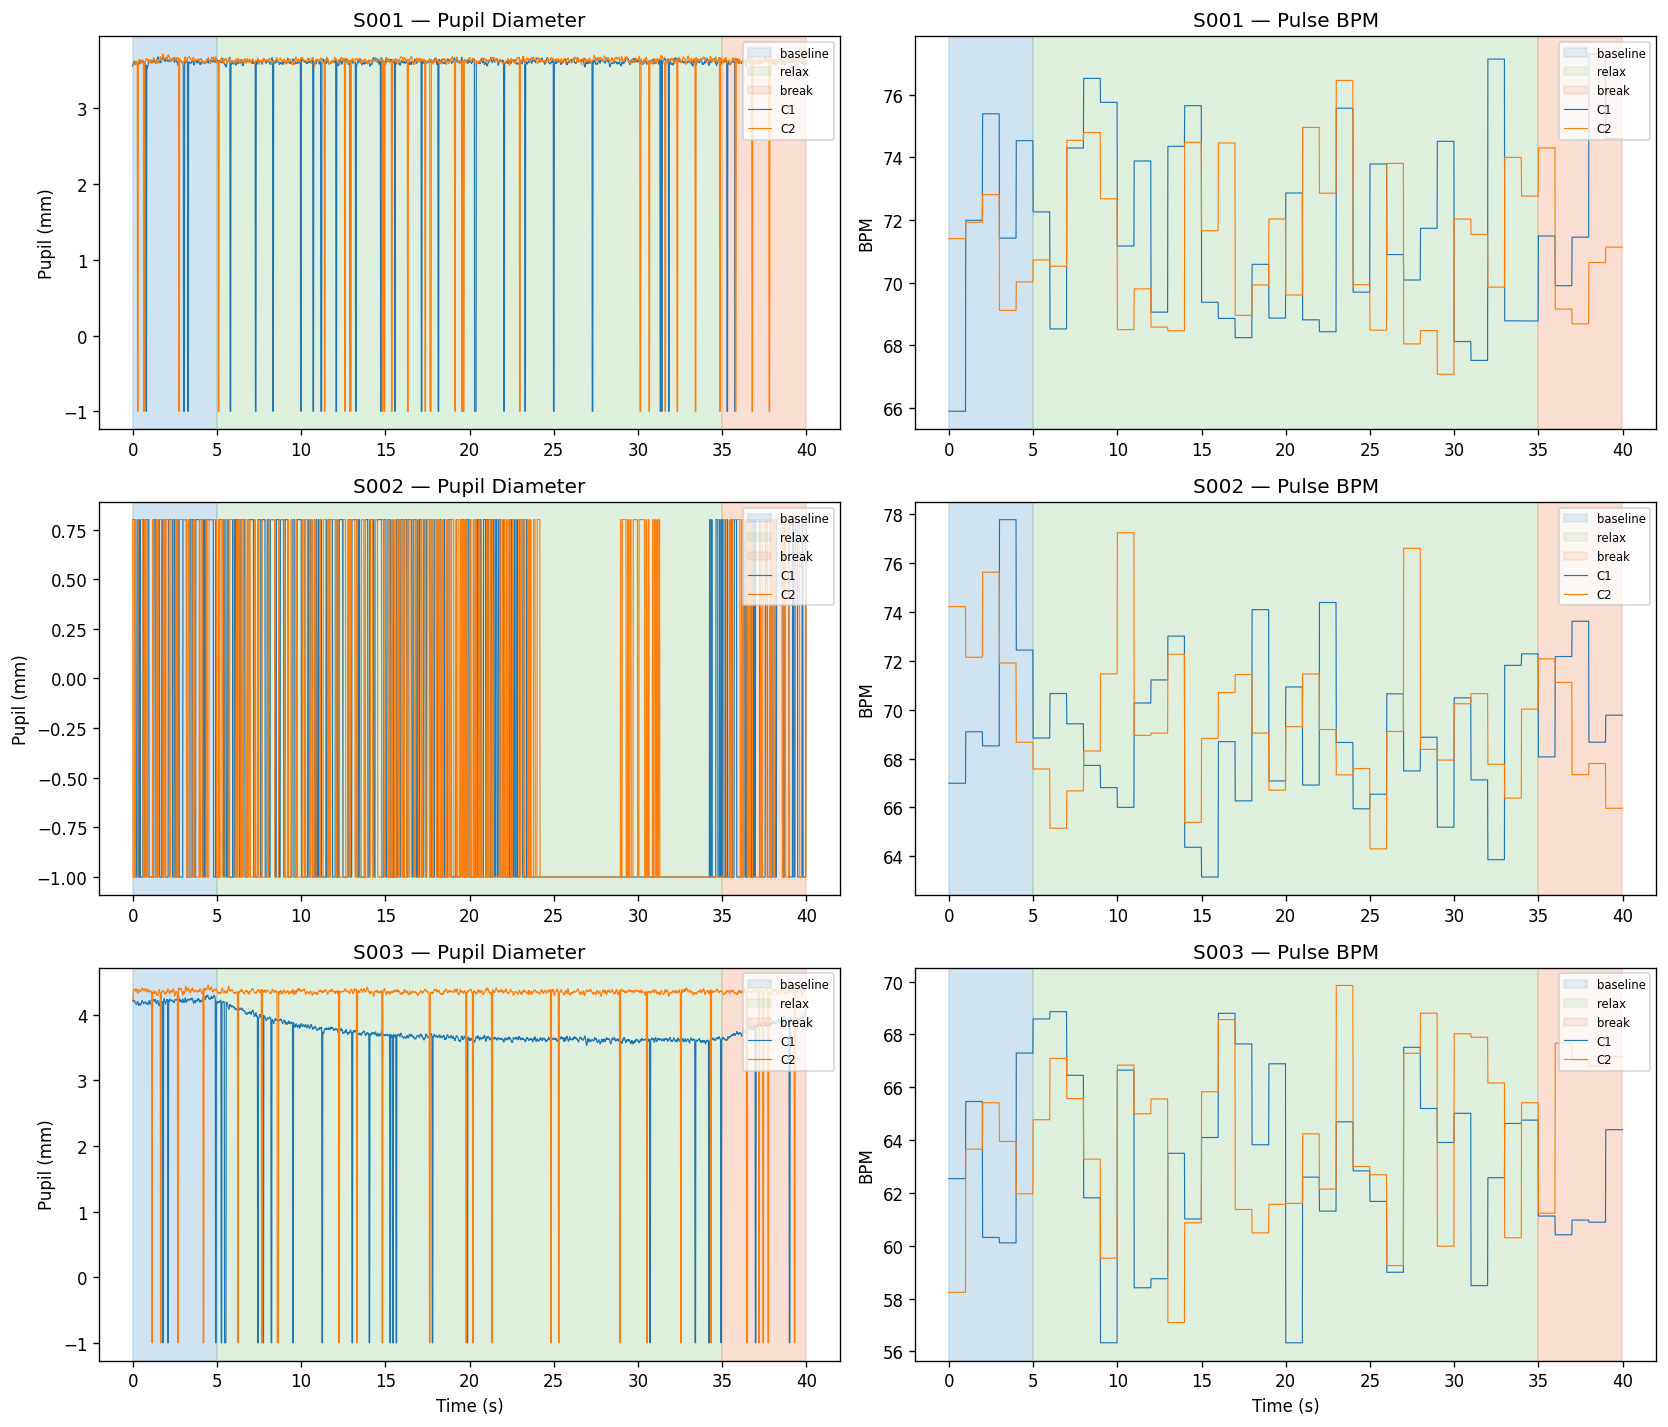

In [3]:
timeseries = pd.read_csv("data/raw/timeseries.csv")
sample_subjects = timeseries["SubjectID"].unique()[:3]

fig = plot_raw_signals(timeseries, sample_subjects, cycle_ids=[1, 2])
plt.show()

del timeseries  # free memory

---
## Data validation — trial signal quality

The validation pipeline (run in `main.py`) applies sample-level masks to flag invalid
data points, then aggregates to trial- and subject-level quality scores.

**Sample-level masks** (per modality, combined with motion):  
- `pupil_valid` — non-missing pupil diameter within median ± k·MAD  
- `bpm_valid` — PPG signal quality ≥ threshold  
- `gaze_valid` — non-missing gaze without velocity jumps  
- `motion_valid` — motion magnitude ≤ median + k·MAD  

Each modality mask is AND-ed with `motion_valid` since excessive motion corrupts all sensors.

**Trial quality score** — weighted combination (0.4 pupil + 0.4 BPM + 0.2 gaze), mapped to:  
- 2 (good): ≥ 0.9  
- 1 (acceptable): 0.6–0.9  
- 0 (poor): < 0.6

In [4]:
print("Trial quality score distribution:")
print(trial_scores["quality_score"].value_counts().sort_index())
print(f"\nTrials excluded (score=0): {(trial_scores['quality_score'] == 0).sum()}")
print()
print("Subject-level quality summary:")
subject_scores.describe()

Trial quality score distribution:
quality_score
0     313
1     982
2    3705
Name: count, dtype: int64

Trials excluded (score=0): 313

Subject-level quality summary:


,mean_quality,n_valid_trials
count,495.000000,495.000000
mean,1.695354,9.468687
std,0.481057,1.468471
min,0.100000,1.000000
25%,1.300000,10.000000
50%,2.000000,10.000000
75%,2.000000,10.000000
max,2.000000,10.000000


### Figure 2 — Data quality overview

Three panels:  
- **A)** Histogram of valid-trial counts per subject  
- **B)** Proportion of quality scores (0/1/2) per CycleID, with top/bottom 5% subjects overlaid  
- **C)** Calibration error vs. mean trial quality

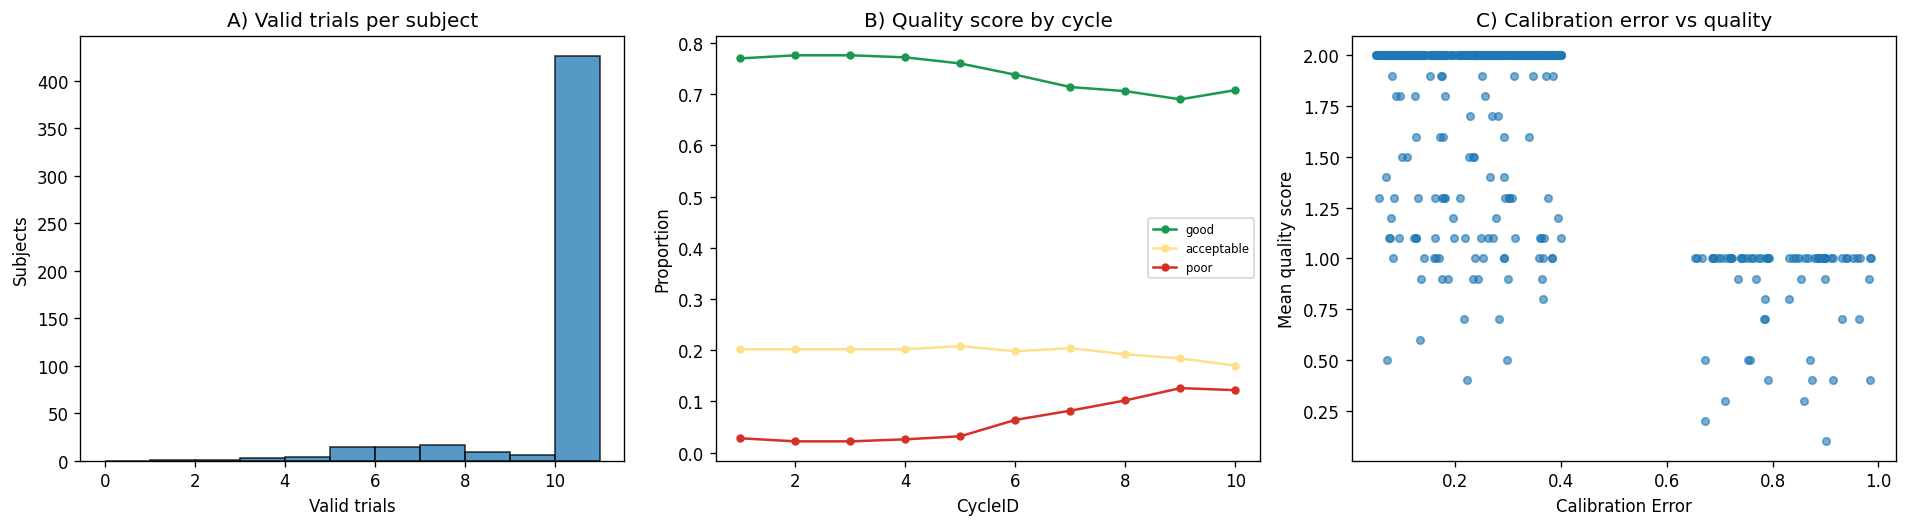

In [5]:
fig = plot_quality_overview(trial_scores, subject_scores, subjects_df=subjects)
plt.show()

---
## Feature extraction

39 features per trial extracted from masked signals, then aggregated to subject level
using median across valid trials. Additionally, **IQR** (inter-quartile range) of each
feature across trials is computed to capture trial-to-trial stability — resulting in
~78 subject-level columns before redundancy removal. Features span baseline state,
response magnitude, temporal adaptation, variability, recovery, and cross-modal coordination.
Pupil-derived features are expected to be most informative given the established link
between tonic pupil diameter and sympathetic arousal (Joshi et al., 2016).

See `src/features.py` for implementation and `data/processed/per_trial_feature_catalog.csv`
for the full per-trial catalog.

In [6]:
print(f"Subject-level features after redundancy removal: {features.shape}")
features.describe().T.head(10)

Subject-level features after redundancy removal: (495, 58)


,count,mean,std,min,25%,50%,75%,max
pupil_baseline_mean,495.0,3.708977,0.681950,2.147804,3.258484,3.676897,4.054374,6.182433
pupil_relax_mean,495.0,3.527459,0.734970,2.109132,2.989055,3.466799,3.964159,6.074616
pupil_relative_delta,495.0,-0.051485,0.079198,-0.259626,-0.120431,-0.002204,0.000887,0.110791
pupil_rebound,494.0,0.036187,0.075619,-0.330251,-0.002220,0.002904,0.098626,0.282241
pupil_relax_slope,495.0,-0.000085,0.000432,-0.005523,-0.000203,-0.000003,0.000002,0.005427
pupil_relax_detrended_std,495.0,0.074059,0.057623,0.021696,0.022781,0.059460,0.103423,0.282843
pupil_relax_p90_p10,495.0,0.271988,0.227036,0.055851,0.059047,0.231373,0.400142,1.088800
pupil_early_late_diff,495.0,-0.065465,0.129174,-0.496591,-0.165921,-0.003194,0.001556,0.596819
pupil_nonlinearity,495.0,-0.025615,0.048588,-0.325925,-0.059269,-0.003267,0.000708,0.241902
bpm_delta,495.0,-1.222050,0.549542,-2.688289,-1.579876,-1.222371,-0.854061,0.726232


---
## Feature exploration

### Redundancy removal

Performed in the pipeline (`main.py`):
1. Removed near-constant features (std ≈ 0)
2. For highly correlated pairs (|r| > 0.95), dropped the feature with higher cross-subject IQR (less stable)

The features loaded above already have redundant columns removed.

### Z-score standardization

Standardize features to zero mean and unit variance for correlation analysis and PCA.

In [7]:
features_z, zscore_params = zscore_standardize(features)

print(f"Standardized features: {features_z.shape}")
print("\nStandardization parameters (first 10):")
zscore_params.head(10)

Standardized features: (495, 58)

Standardization parameters (first 10):


,mean,std
pupil_baseline_mean,3.708977,0.681950
pupil_relax_mean,3.527459,0.734970
pupil_relative_delta,-0.051485,0.079198
pupil_rebound,0.036187,0.075619
pupil_relax_slope,-0.000085,0.000432
pupil_relax_detrended_std,0.074059,0.057623
pupil_relax_p90_p10,0.271988,0.227036
pupil_early_late_diff,-0.065465,0.129174
pupil_nonlinearity,-0.025615,0.048588
bpm_delta,-1.222050,0.549542


### Feature relevance — correlation with STAI scores

Spearman ρ (primary) with Pearson as sanity check. A feature is *stable* if it
ranks in the top 10 by |r| under both methods for at least one target.

Each row below shows:  
- **ρ** — Spearman correlation with the target  
- **stable** — also in Pearson top 10 (✓)  
- **quality-driven** — |ρ| with CalibrationError or mean_quality exceeds the lowest STAI |ρ| in top 10 (⚠)

In [ ]:
stai = subjects.set_index("SubjectID")[["STAI_S", "STAI_T"]]
stai_spearman, stai_pearson, stai_stable = dual_correlation(
    features_z, stai.loc[features_z.index], top_n=10
)

# Confound correlations (Spearman)
confounds = subjects.set_index("SubjectID")[["CalibrationError"]].loc[features_z.index]
confounds["mean_quality"] = subject_scores.loc[features_z.index, "mean_quality"]
confound_corr = feature_target_correlation(features_z, confounds, method="spearman")

tbl, top_union, floor, candidates = build_relevance_table(
    stai_spearman, stai_stable, confound_corr, top_n=10
)
print(f"Top features (union of top-10 per STAI) — confound flag threshold |ρ| > {floor:.4f}")
display(tbl)

Top features (union of top-10 per STAI) — confound flag threshold |ρ| > 0.1939


,ρ STAI_S,stable_S,ρ STAI_T,stable_T,quality-driven
feature,,,,,
pupil_auc_relax_iqr,-0.2057,✓,-0.2254,✓,
pupil_baseline_mean,+0.2170,✓,+0.2096,✓,
pupil_early_late_diff,+0.2802,✓,+0.3317,✓,
pupil_nonlinearity,+0.2734,✓,+0.3249,✓,
pupil_rebound,-0.2399,✓,-0.2771,✓,
pupil_relative_delta,+0.3157,✓,+0.3766,✓,
pupil_relative_delta_iqr,-0.2094,✓,-0.2234,✓,
pupil_relax_mean,+0.3131,✓,+0.3275,✓,
pupil_relax_p90_p10,-0.1939,✓,-0.2145,✓,⚠


### Confounding factors — continuous

Spearman correlation of features with CalibrationError and mean trial quality.
Features strongly driven by data quality or calibration are less desirable as biomarkers (H4).

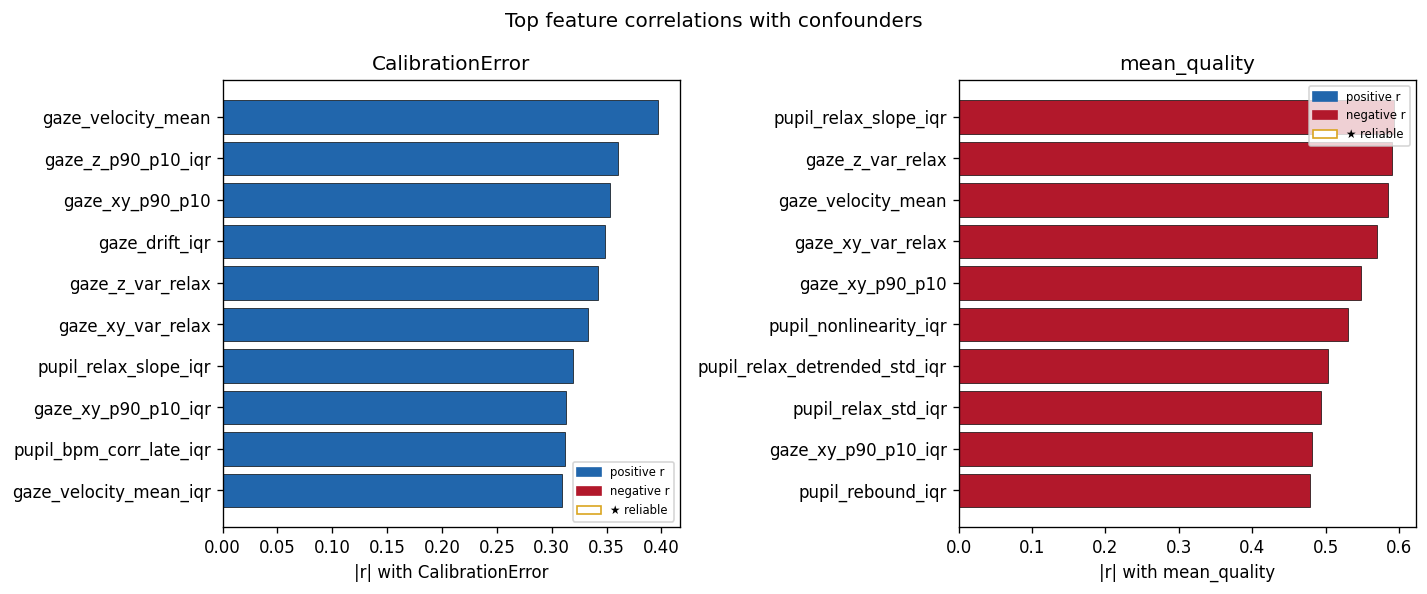

In [ ]:
fig = plot_confound_corr(
    confound_corr,
    confound_cols=("CalibrationError", "mean_quality"),
    top_n=10,
    stable=stai_stable,
)
plt.show()

### Feature scatter — top features vs STAI scores

Scatter plots of the top 3 features (by |Spearman ρ|) against each STAI score,
colored by calibration error.  
- **STAI_S** (state): delta / slope / response features reflect current phasic relaxation response  
- **STAI_T** (trait): baseline / IQR / stability features reflect tonic arousal level and stable predisposition

e:\repos\biomarker-assignment\src\plotting.py:380: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


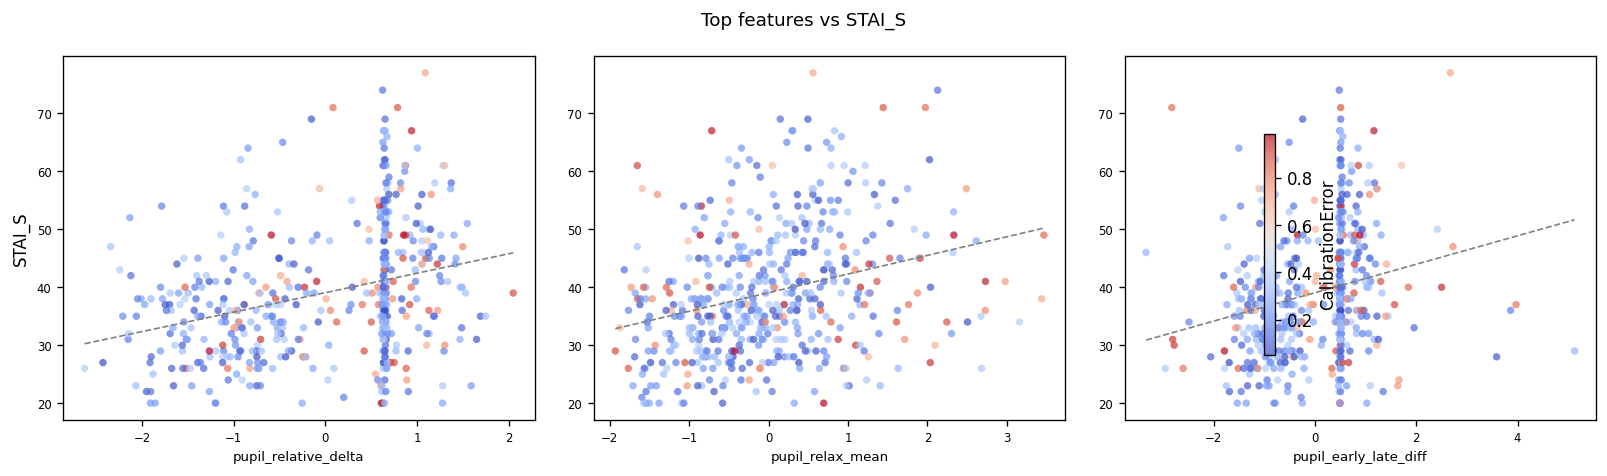

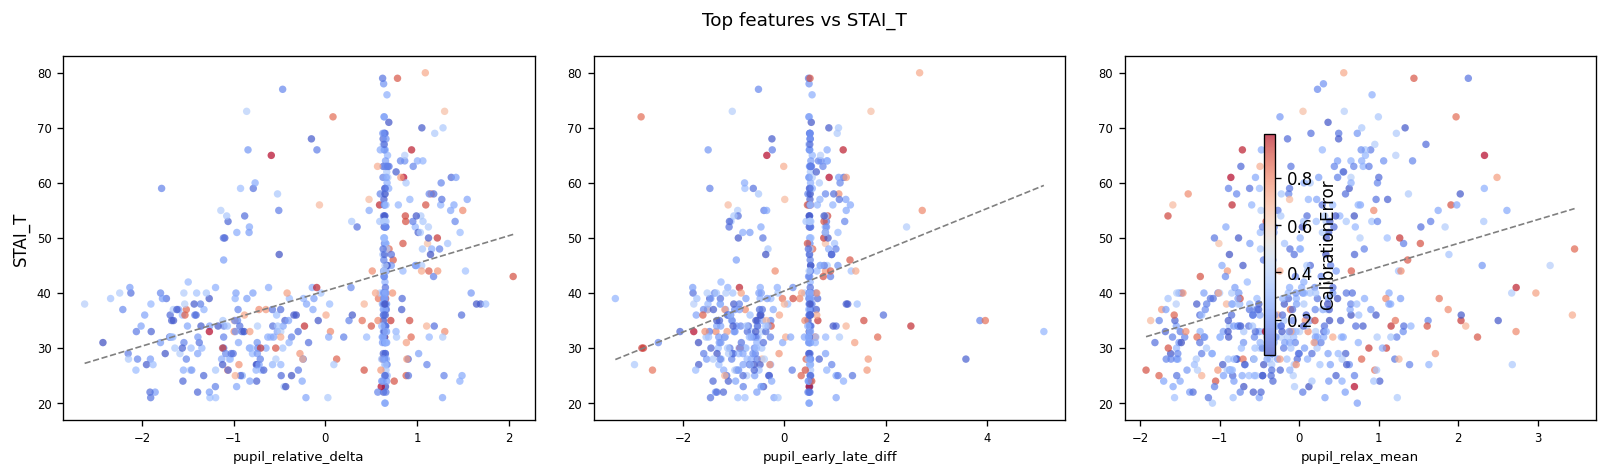

In [10]:
cal_error = subjects.set_index("SubjectID")["CalibrationError"].loc[features_z.index]
cal_error.name = "CalibrationError"

figs = plot_feature_scatter(
    features_z,
    stai.loc[features_z.index],
    color_by=cal_error,
    target_cols=["STAI_S", "STAI_T"],
    top_n=3,
    stai_feature_correlations=stai_spearman,
)
for f in figs:
    plt.show()

### Biomarker sensitivity — permutation test

To confirm that the STAI associations are not due to chance, we run a permutation test
on the **stable, non-quality-driven** candidate features. For each feature, STAI labels
are shuffled 1000× and Spearman ρ is recomputed, producing a null distribution. The
empirical p-value is the proportion of null |ρ| values that exceed the observed |ρ|.

Features with p < 0.05 have associations unlikely to arise from random label assignment.

In [ ]:
perm_features = sorted(candidates)
print(f"Testing {len(perm_features)} candidate features: {perm_features}")

perm_observed, perm_pvalues, perm_null = permutation_test(
    features_z, stai.loc[features_z.index], perm_features,
)

print("\nPermutation p-values:")
display(perm_pvalues.round(4))

figs = plot_permutation_null(
    perm_observed, perm_null, perm_pvalues, target_cols=["STAI_S", "STAI_T"],
)
for f in figs:
    plt.show()

---
## Dimensionality reduction — PCA

Fit PCA on z-scored features to identify low-dimensional structure.  
1. Scree plot — explained variance per PC and cumulative  
2. PC1 vs PC2 colored by STAI scores, CalibrationError, and mean quality  
3. Spearman correlations of PCs with targets & confounders  
4. Top loadings — which features drive each PC

PCA was chosen as the required exploratory dimensionality reduction method.
Clustering was considered but not pursued, since PCA already reveals a separation
between data-quality-driven and anxiety-related physiological variation.

Components: 58
Variance explained — PC1: 23.4%, PC2: 9.6%, cumulative(2): 33.0%


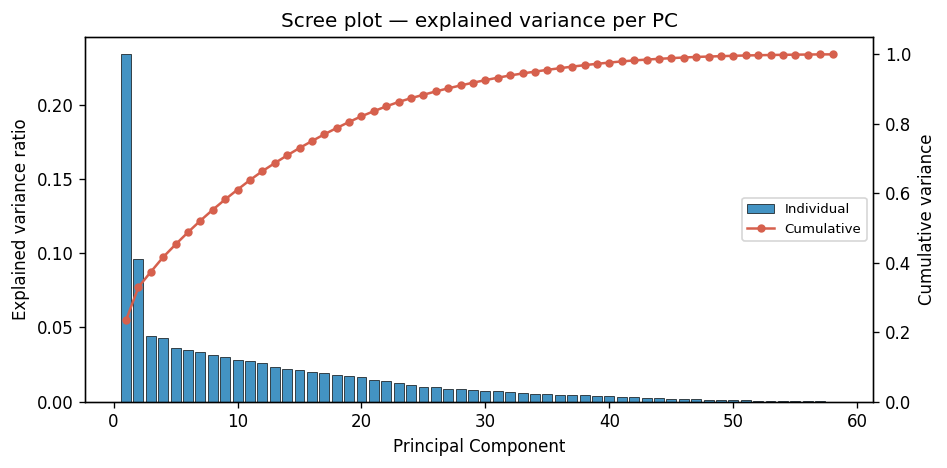

In [11]:
pca_scores, pca_var, pca_loadings = fit_pca(features_z)

print(f"Components: {len(pca_var)}")
print(f"Variance explained — PC1: {pca_var[0]:.1%}, PC2: {pca_var[1]:.1%}, "
      f"cumulative(2): {pca_var[:2].sum():.1%}")

fig = plot_scree(pca_var)
plt.show()

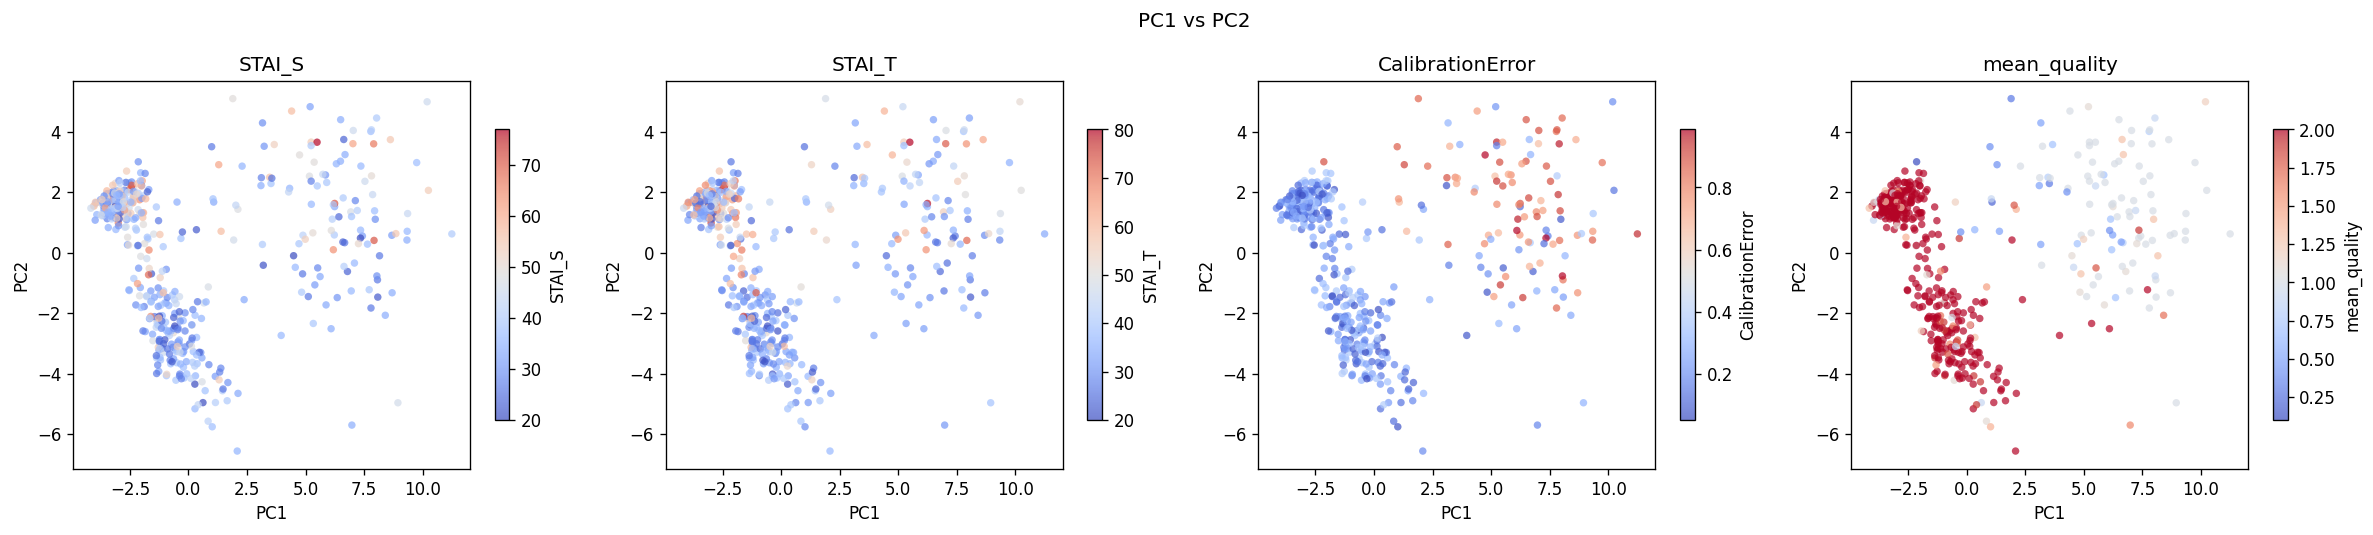

In [12]:
# PC1 vs PC2 colored by STAI_S, STAI_T, CalibrationError, mean quality
color_vars = {
    "STAI_S": stai.loc[features_z.index, "STAI_S"],
    "STAI_T": stai.loc[features_z.index, "STAI_T"],
    "CalibrationError": subjects.set_index("SubjectID")["CalibrationError"].loc[features_z.index],
    "mean_quality": subject_scores.loc[features_z.index, "mean_quality"],
}

fig = plot_pca_colored(pca_scores, color_vars)
plt.show()

### PC correlations & candidate summary

Spearman correlations of PC1–PC5 with STAI scores and confounders,
plus candidate biomarkers' loadings and metadata confounder tests.

In [ ]:
n_pcs = min(5, pca_scores.shape[1])
pc_cols = pca_scores[pca_scores.columns[:n_pcs]]

targets = stai.loc[features_z.index].copy()
targets["CalibrationError"] = subjects.set_index("SubjectID")["CalibrationError"].loc[features_z.index]
targets["mean_quality"] = subject_scores.loc[features_z.index, "mean_quality"]

pc_corr = feature_target_correlation(pc_cols, targets, method="spearman")
print("Spearman correlations — PCs vs targets & confounders:")
display(pc_corr.round(4))

Spearman correlations — PCs vs targets & confounders:


,STAI_S,STAI_T,CalibrationError,mean_quality
PC1,-0.1479,-0.1474,0.3346,-0.5823
PC2,0.2791,0.3251,0.2081,-0.2295
PC3,0.1032,0.1262,-0.0485,0.0568
PC4,0.0569,0.0665,-0.0877,0.1163
PC5,-0.0036,-0.0005,-0.0483,-0.0289


**Interpretation:**  
- PC1 is primarily associated with data quality and calibration error  
- PC2 shows the strongest association with STAI_S and STAI_T — it captures the main physiological variation related to anxiety, consistent with a shared autonomic arousal axis across pupil features  
- PC3 shows weak but relatively clean associations  
- Higher components (PC4–PC5) show negligible signal

In [ ]:
candidate_tbl, cand_feats = build_candidate_table(
    pca_loadings, stai_spearman, candidates, stai_stable,
    confound_corr, floor, pcs=("PC2", "PC3"), top_n=10,
)

# H5 metadata tests on candidates
meta = subjects.set_index("SubjectID")[["Gender", "WearsGlasses", "Handedness", "BloodType"]]
meta = meta.loc[features_z.index]
h5_pvals, h5_effects = metadata_group_tests(features_z[cand_feats], meta)

binary_cols = ["Gender", "WearsGlasses", "Handedness"]
multi_cols = ["BloodType"]
h5_display = format_h5_display(h5_pvals, h5_effects, binary_cols, multi_cols)
candidate_tbl = candidate_tbl.join(h5_display, on="feature")

# Styled display
styled = style_loadings_table(candidate_tbl, binary_cols + multi_cols)
display(styled)

Saved to output\loadings_summary.csv


**Metadata confounder tests (H5)** — Mann-Whitney U + Cohen's d for binary variables
(Gender, WearsGlasses, Handedness); Kruskal-Wallis + η² for BloodType.
⚠ flags require both p < 0.05 *and* a meaningful effect size (|d| ≥ 0.3 / η² ≥ 0.04;
Cohen, 1988). With N≈500, even trivial effects reach statistical significance; we flag
based on effect magnitude to identify practically relevant confounders.

In [ ]:
# Candidate loadings — highlighted in PC2/PC3 top loaders
fig = plot_candidate_loadings(pca_loadings, candidates, pcs=("PC2", "PC3"), top_n=10)
plt.show()

In [ ]:
# Candidate summary — STAI correlations + H5 effect sizes
fig = plot_candidate_summary(
    candidates, stai_spearman, h5_effects, h5_pvals,
)
plt.show()

---
## Conclusion

- Physiological signals showed clear structure during the relaxation task, supporting **H1**.
  Pupil-based features captured consistent variation across subjects.

- Baseline-normalized and response features (e.g. `pupil_relative_delta`,
  `pupil_early_late_diff`, `pupil_nonlinearity`) showed the strongest associations
  with anxiety, supporting **H2**.

- PCA revealed a clear separation of signal and confounds:
  - **PC1**: dominated by data quality (ρ with quality, calibration)
  - **PC2**: main physiological axis associated with anxiety (ρ with STAI)
  - **PC3**: baseline pupil level with weaker associations

- The 6 candidate biomarkers were selected through a multi-step funnel:
  dual-correlation stability (Spearman ∩ Pearson), quality-independence, and
  permutation testing (all p=0.001, 1000 permutations). Their PC2/PC3 loadings
  confirm they contribute to the anxiety-related principal components.

- This partially supports **H3**: candidate biomarkers show consistent association
  with STAI, weak dependence on confounds, and convergence across multiple pupil
  features rather than a single isolated marker.

- **H4** is addressed through the confound analysis: top features were checked
  against calibration error and data quality; features that survive both the
  stability check (Spearman + Pearson agreement) and the quality-independence check
  are the strongest biomarker candidates.

- **H5** was evaluated via group statistical tests on the 6 candidates. Flags require
  both statistical significance (p < 0.05) *and* meaningful effect size (|d| ≥ 0.3
  or η² ≥ 0.04), since N≈500 makes trivial effects statistically significant.

The dominance of pupil features likely reflects both the strong LC-NE → pupil pathway
and the lower signal-to-noise ratio of PPG-based heart rate in a VR headset, where
motion artifacts degrade pulse detection. Overall, anxiety is reflected in a
multi-dimensional pupil response combining magnitude (delta), dynamics (nonlinearity,
slope, early–late), and sustained activation (relax mean).